In [1]:
from VRT import VRT
from MORES import MORES
import numpy as np
from postprocessing import Mueller2sigma0VH
import matplotlib.pyplot as plt

In [2]:
mores = MORES()
mores.init_from_model_file("./model.toml")
vrt = VRT(mores)
vrt.Mue_volume((30, 180, 30, 0))

: 

: 

In [3]:
vrt.Mue_surface((30, 180, 30, 0))

array([[ 2.07430301e-03,  2.92556692e-35, -2.45934267e-19,
        -2.46403315e-22],
       [ 1.57368512e-35,  1.80226958e-03,  1.68144319e-19,
         3.08961203e-22],
       [-3.60749902e-19,  4.58522237e-19, -1.92147746e-03,
         3.82866918e-06],
       [-1.35259262e-21,  1.35758066e-21, -3.82866918e-06,
        -1.92147746e-03]])

In [10]:
theta_is = np.linspace(1, 70, 70)
Num = len(theta_is)
sigma0_VV_dB = np.zeros(Num)
sigma0_HH_dB = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    Mue = vrt.Mue_surface((theta_i, 180, theta_i, 0))
    sigma_VV, _, _, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VV_dB[i] = 10*np.log10(sigma_VV)
    sigma0_HH_dB[i] = 10*np.log10(sigma_HH)


Text(0, 0.5, '$\\sigma^0$ (dB)')

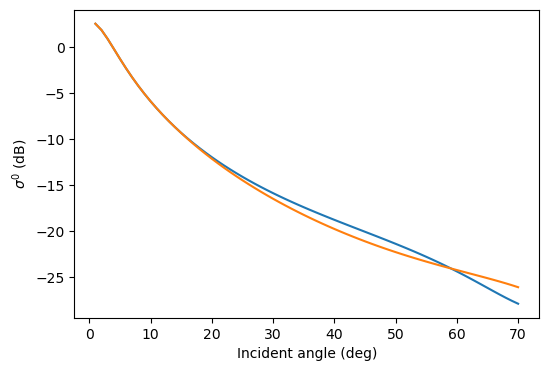

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(theta_is, sigma0_VV_dB)
plt.plot(theta_is, sigma0_HH_dB)
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')

In [18]:
vrt.Mue_volume((30, 180, 30, 0))

AttributeError: module 'numpy' has no attribute 'acos'